In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
import pandas as pd

print("=== 1. LOAD DATA ===")

df_raw = pd.read_excel("data/ALL IN OUT SO PNK 2021 - 2025.xlsx", engine='openpyxl')

print("Jumlah Data:", df_raw.shape)
display(df_raw.head())
print("-" * 50)

=== 1. LOAD DATA ===
Jumlah Data: (60798, 5)


,SN,TANGGAL,TIPE,TEKNISI,NIK
0,FHTT96FCB8C8,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
1,FHTT96FC9918,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
2,FHTT96FC5F78,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
3,0010049900E06800062010DC4AF46BC6,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179
4,0010049900E06800062010DC4AF458D8,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179


--------------------------------------------------


In [3]:
# =============================================================================
# 2. DATA CLEANING
# =============================================================================
print("=== 2. DATA CLEANING ===")
 
df_clean = df_raw.copy()
df_clean.columns = df_clean.columns.str.strip().str.upper()
 
missing = df_clean[['TANGGAL', 'TEKNISI', 'TIPE']].isnull().sum()
print("Missing Value:\n", missing)
 
missing_mask = df_clean[['TANGGAL', 'TEKNISI', 'TIPE']].isnull().any(axis=1)
missing_rows = df_clean[missing_mask]
 
if not missing_rows.empty:
    print(f"\nDetail baris mengandung missing value ({len(missing_rows)} baris):")
    display(missing_rows)
else:
    print("\nTidak ada baris yang mengandung missing value.")
 
df_clean = df_clean.dropna(subset=['TANGGAL', 'TEKNISI', 'TIPE'])
 
duplicate_mask = df_clean.duplicated(keep=False)
duplicate_rows = df_clean[duplicate_mask].sort_values(list(df_clean.columns))
 
if not duplicate_rows.empty:
    print(f"\nDetail baris duplikat ({df_clean.duplicated().sum()} baris akan dihapus):")
    display(duplicate_rows)
else:
    print("\nTidak ada baris duplikat.")
 
df_clean = df_clean.drop_duplicates()
print("\nData setelah cleaning:", df_clean.shape)
display(df_clean.head())
print("-" * 50)

=== 2. DATA CLEANING ===
Missing Value:
 TANGGAL    0
TEKNISI    8
TIPE       9
dtype: int64

Detail baris mengandung missing value (17 baris):


,SN,TANGGAL,TIPE,TEKNISI,NIK
30426,ZTEGD113045B,2022-10-29,ONT_ZTE_F670L,NaN,NaN
30656,ZTEGD19FAA36,2022-11-06,ONT_ZTE_F670L,NaN,NaN
38003,0010049900E0680010212025D28FC96F,2023-07-10,NaN,FAISAL R,15901194
43642,ZTEGD4A1E739,2024-01-20,NaN,MUH ILHAM SAPUTRA,16941908
43669,ZTEGD08394E8,2024-01-22,NaN,WAHYUDI,16960716
43673,FHTT9D281578,2024-01-22,NaN,ALFRIFAL SHEIKH,16000401
43674,ZTEGD4A1E756,2024-01-22,NaN,FAISAL NUGRAHA.A,16952105
43675,FHTT9DB4B8D0,2024-01-22,NaN,FAISAL NUGRAHA.A,16952105
43677,ZTEGD083E27A,2024-01-22,NaN,ADI,16002177
43678,ZTEGCE7DCF40,2024-01-22,NaN,ADI,16002177



Detail baris duplikat (3796 baris akan dihapus):


,SN,TANGGAL,TIPE,TEKNISI,NIK
12549,001004990070424000009C2F4E285781,2021-08-28,SetTopBox_ZTE_B860H_V5.0,MUH MUFTI ISK,16992816
16319,001004990070424000009C2F4E285781,2021-08-28,SetTopBox_ZTE_B860H_V5.0,MUH MUFTI ISK,16992816
42447,00100499007042400000C4741E307A7E,2023-12-21,SetTopBox_ZTE_B860H_V5.0,OKTAVIANIS YAN MANGGA,16040215
42450,00100499007042400000C4741E307A7E,2023-12-21,SetTopBox_ZTE_B860H_V5.0,OKTAVIANIS YAN MANGGA,16040215
11593,0010049900E068000321A0D83D174BC9,2021-08-10,SetTopBoxIPTV_FIBERHOME_HG680FJ,ASRI ARIF,16983259
...,...,...,...,...,...
46850,ZTEGD4A359A7,2024-05-03,ONT_ZTE_F670 V2.0,MUHAMMAD FAHRIZAL,NaN
46628,ZTEGD4A359AA,2024-04-26,ONT_ZTE_F670 V2.0,ANDI KURNIA DHARMAWAN APPA,16030570
46630,ZTEGD4A359AA,2024-04-26,ONT_ZTE_F670 V2.0,ANDI KURNIA DHARMAWAN APPA,16030570
46844,ZTEGD4A359AE,2024-05-03,ONT_ZTE_F670 V2.0,MUHAMMAD FAHRIZAL,NaN



Data setelah cleaning: (56985, 5)


,SN,TANGGAL,TIPE,TEKNISI,NIK
0,FHTT96FCB8C8,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
1,FHTT96FC9918,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
2,FHTT96FC5F78,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
3,0010049900E06800062010DC4AF46BC6,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179
4,0010049900E06800062010DC4AF458D8,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179


--------------------------------------------------


In [4]:
# =============================================================================
# 3. KONVERSI TANGGAL
# =============================================================================
print("=== 3. KONVERSI TANGGAL ===")
 
df_clean['TANGGAL'] = pd.to_datetime(df_clean['TANGGAL'], errors='coerce')
df_clean = df_clean.dropna(subset=['TANGGAL'])
 
print("Rentang tanggal:")
print(df_clean['TANGGAL'].min(), "s/d", df_clean['TANGGAL'].max())
display(df_clean.head())
print("-" * 50)

=== 3. KONVERSI TANGGAL ===
Rentang tanggal:
2021-01-01 00:00:00 s/d 2025-08-29 00:00:00


,SN,TANGGAL,TIPE,TEKNISI,NIK
0,FHTT96FCB8C8,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
1,FHTT96FC9918,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
2,FHTT96FC5F78,2021-01-01,ONT_FIBERHOME_HG6243C,ADI,16002177
3,0010049900E06800062010DC4AF46BC6,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179
4,0010049900E06800062010DC4AF458D8,2021-01-01,SetTopBoxIPTV_FIBERHOME_HG680-P,EDI GUNAWAN RAMLI,16002179


--------------------------------------------------


In [5]:
# =============================================================================
# 4. AGREGASI & LABELING
# =============================================================================
print("=== 4. AGREGASI & LABELING ===")
 
df_per_tipe = df_clean.groupby(
    ['TANGGAL', 'TEKNISI', 'TIPE']
).size().reset_index(name='JUMLAH_PER_TIPE')
 
df_daily = df_per_tipe.groupby(['TANGGAL', 'TEKNISI']).agg(
    JUMLAH_TIPE=('TIPE', 'nunique'),
    TOTAL_PENGAMBILAN=('JUMLAH_PER_TIPE', 'sum')
).reset_index()
 
def label_status(group):
    return 'TIDAK PATUH' if (group['JUMLAH_PER_TIPE'] > 3).any() else 'PATUH'
 
status_map = df_per_tipe.groupby(
    ['TANGGAL', 'TEKNISI']
).apply(label_status).reset_index()
status_map.columns = ['TANGGAL', 'TEKNISI', 'STATUS']
 
df_daily = df_daily.merge(status_map, on=['TANGGAL', 'TEKNISI'], how='left')
 
print("Distribusi Status:")
print(df_daily['STATUS'].value_counts())
display(df_daily.head())
print("-" * 50)

=== 4. AGREGASI & LABELING ===
Distribusi Status:
STATUS
PATUH          13487
TIDAK PATUH     4328
Name: count, dtype: int64


,TANGGAL,TEKNISI,JUMLAH_TIPE,TOTAL_PENGAMBILAN,STATUS
0,2021-01-01,ADI,1,3,PATUH
1,2021-01-01,EDI GUNAWAN RAMLI,4,10,TIDAK PATUH
2,2021-01-02,EDI GUNAWAN RAMLI,2,7,TIDAK PATUH
3,2021-01-02,MUH.SURYA,1,10,TIDAK PATUH
4,2021-01-02,RACHMAT AL QADRI ARIEF,1,1,PATUH


--------------------------------------------------


In [6]:
# =============================================================================
# 5. LABEL ENCODING
# =============================================================================
from sklearn.preprocessing import LabelEncoder
import pickle
 
print("=== 5. LABEL ENCODING ===")
 
le_teknisi = LabelEncoder()
df_daily['TEKNISI_ENC'] = le_teknisi.fit_transform(df_daily['TEKNISI'])
 
print("Mapping TEKNISI (5 sampel):")
teknisi_mapping = dict(zip(
    le_teknisi.classes_,
    le_teknisi.transform(le_teknisi.classes_)
))
print(dict(list(teknisi_mapping.items())[:5]))
 
le_status = LabelEncoder()
df_daily['STATUS_ENC'] = le_status.fit_transform(df_daily['STATUS'])
 
print("\nMapping STATUS:")
print(dict(zip(
    le_status.classes_,
    le_status.transform(le_status.classes_)
)))
# PATUH = 0, TIDAK PATUH = 1 (urutan alfabetis)
 
display(df_daily.head())
 
df_daily.to_excel("hasil_label_encoding.xlsx", index=False)
print("\nFile hasil_label_encoding.xlsx berhasil disimpan.")
print("-" * 50)

=== 5. LABEL ENCODING ===
Mapping TEKNISI (5 sampel):
{'ABD RAZAK IMRAN': 0, 'ABDUL DJABBAR ASSYRI': 1, 'ABDUL MUTTALIB': 2, 'ABDUL WAHAB TANGKELANGI': 3, 'ACHMAD IQRAMAWARDANA': 4}

Mapping STATUS:
{'PATUH': 0, 'TIDAK PATUH': 1}


,TANGGAL,TEKNISI,JUMLAH_TIPE,TOTAL_PENGAMBILAN,STATUS,TEKNISI_ENC,STATUS_ENC
0,2021-01-01,ADI,1,3,PATUH,6,0
1,2021-01-01,EDI GUNAWAN RAMLI,4,10,TIDAK PATUH,74,1
2,2021-01-02,EDI GUNAWAN RAMLI,2,7,TIDAK PATUH,74,1
3,2021-01-02,MUH.SURYA,1,10,TIDAK PATUH,178,1
4,2021-01-02,RACHMAT AL QADRI ARIEF,1,1,PATUH,208,0



File hasil_label_encoding.xlsx berhasil disimpan.
--------------------------------------------------


In [7]:
# =============================================================================
# 6. FEATURE SELECTION
# =============================================================================
print("=== 6. FEATURE SELECTION ===")
 
FEATURES = ['JUMLAH_TIPE', 'TOTAL_PENGAMBILAN', 'TEKNISI_ENC']
TARGET   = 'STATUS_ENC'
 
X = df_daily[FEATURES]
y = df_daily[TARGET]
 
print("Fitur yang digunakan:", FEATURES)
print("Target:", TARGET)
display(X.head())
print("-" * 50)

=== 6. FEATURE SELECTION ===
Fitur yang digunakan: ['JUMLAH_TIPE', 'TOTAL_PENGAMBILAN', 'TEKNISI_ENC']
Target: STATUS_ENC


,JUMLAH_TIPE,TOTAL_PENGAMBILAN,TEKNISI_ENC
0,1,3,6
1,4,10,74
2,2,7,74
3,1,10,178
4,1,1,208


--------------------------------------------------


In [8]:
# =============================================================================
# 7. SPLIT DATA
# =============================================================================
from sklearn.model_selection import train_test_split
 
print("=== 7. SPLIT DATA ===")
 
scenarios = {
    "90:10": 0.10,
    "80:20": 0.20,
    "70:30": 0.30,
}
 
splits = {}
 
for label, test_size in scenarios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    splits[label] = (X_train, X_test, y_train, y_test)
 
    print(f"\n--- Skenario {label} ---")
    print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
    print("Distribusi Train:", dict(y_train.value_counts()))
    print("Distribusi Test :", dict(y_test.value_counts()))
 
print("-" * 50)

=== 7. SPLIT DATA ===

--- Skenario 90:10 ---
Train : (16033, 3)  |  Test : (1782, 3)
Distribusi Train: {0: 12138, 1: 3895}
Distribusi Test : {0: 1349, 1: 433}

--- Skenario 80:20 ---
Train : (14252, 3)  |  Test : (3563, 3)
Distribusi Train: {0: 10790, 1: 3462}
Distribusi Test : {0: 2697, 1: 866}

--- Skenario 70:30 ---
Train : (12470, 3)  |  Test : (5345, 3)
Distribusi Train: {0: 9441, 1: 3029}
Distribusi Test : {0: 4046, 1: 1299}
--------------------------------------------------


In [9]:
# =============================================================================
# 8. SMOTE (OVERSAMPLING)
# =============================================================================
from imblearn.over_sampling import SMOTE
 
print("=== 8. SMOTE ===")
 
smote_results = {}
 
for label, (X_train, X_test, y_train, y_test) in splits.items():
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
    print(f"\nSkenario {label}")
    print(f"  Sebelum SMOTE : {dict(pd.Series(y_train).value_counts())}")
    print(f"  Setelah SMOTE : {dict(pd.Series(y_train_res).value_counts())}")
 
    smote_results[label] = {
        "X_train_res": X_train_res,
        "y_train_res": y_train_res,
        "X_test"     : X_test,
        "y_test"     : y_test,
    }
 
print("-" * 50)

=== 8. SMOTE ===

Skenario 90:10
  Sebelum SMOTE : {0: 12138, 1: 3895}
  Setelah SMOTE : {0: 12138, 1: 12138}

Skenario 80:20
  Sebelum SMOTE : {0: 10790, 1: 3462}
  Setelah SMOTE : {0: 10790, 1: 10790}

Skenario 70:30
  Sebelum SMOTE : {0: 9441, 1: 3029}
  Setelah SMOTE : {0: 9441, 1: 9441}
--------------------------------------------------


In [10]:
# =============================================================================
# 8. SMOTE (OVERSAMPLING)
# =============================================================================
from imblearn.over_sampling import SMOTE
 
print("=== 8. SMOTE ===")
 
smote_results = {}
 
for label, (X_train, X_test, y_train, y_test) in splits.items():
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
    print(f"\nSkenario {label}")
    print(f"  Sebelum SMOTE : {dict(pd.Series(y_train).value_counts())}")
    print(f"  Setelah SMOTE : {dict(pd.Series(y_train_res).value_counts())}")
 
    smote_results[label] = {
        "X_train_res": X_train_res,
        "y_train_res": y_train_res,
        "X_test"     : X_test,
        "y_test"     : y_test,
    }
 
print("-" * 50)

=== 8. SMOTE ===

Skenario 90:10
  Sebelum SMOTE : {0: 12138, 1: 3895}
  Setelah SMOTE : {0: 12138, 1: 12138}

Skenario 80:20
  Sebelum SMOTE : {0: 10790, 1: 3462}
  Setelah SMOTE : {0: 10790, 1: 10790}

Skenario 70:30
  Sebelum SMOTE : {0: 9441, 1: 3029}
  Setelah SMOTE : {0: 9441, 1: 9441}
--------------------------------------------------


=== 9. SCALING ===

Skenario 90:10 — data setelah scaling:


,JUMLAH_TIPE,TOTAL_PENGAMBILAN,TEKNISI_ENC
0,-0.636465,-0.796454,-1.634432
1,-0.636465,0.653306,-0.654889
2,-0.636465,-0.796454,-0.029398
3,-0.636465,-0.796454,0.926542
4,-0.636465,0.290866,-1.138760


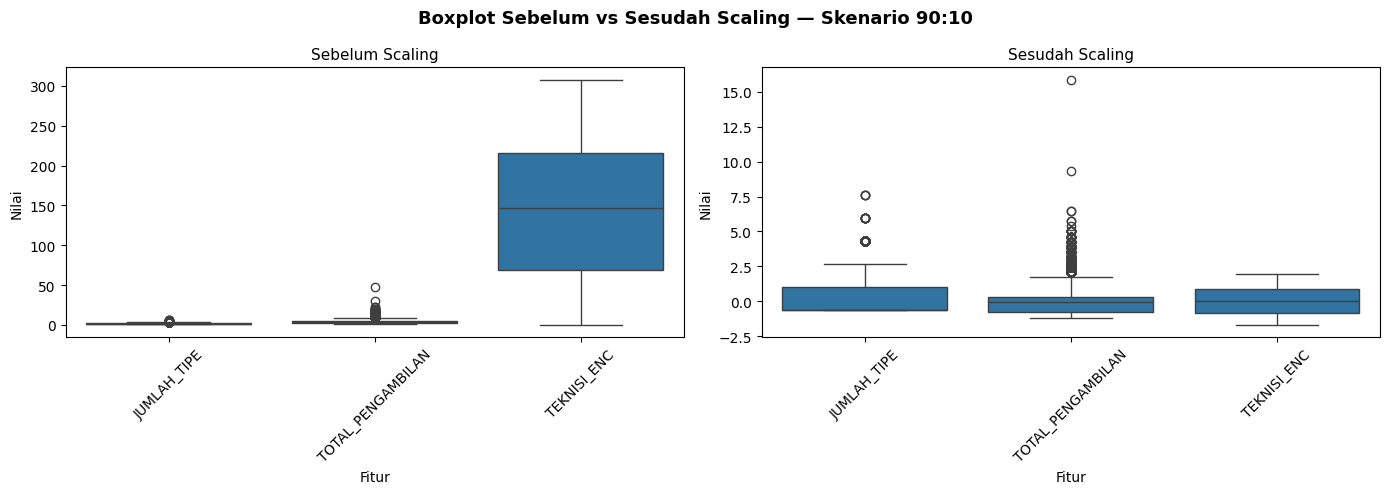


Skenario 80:20 — data setelah scaling:


,JUMLAH_TIPE,TOTAL_PENGAMBILAN,TEKNISI_ENC
0,1.011711,-0.068231,-1.688613
1,2.663454,-0.068231,1.371474
2,-0.640031,2.113677,-0.022697
3,1.011711,2.113677,1.525069
4,-0.640031,-0.068231,-1.251458


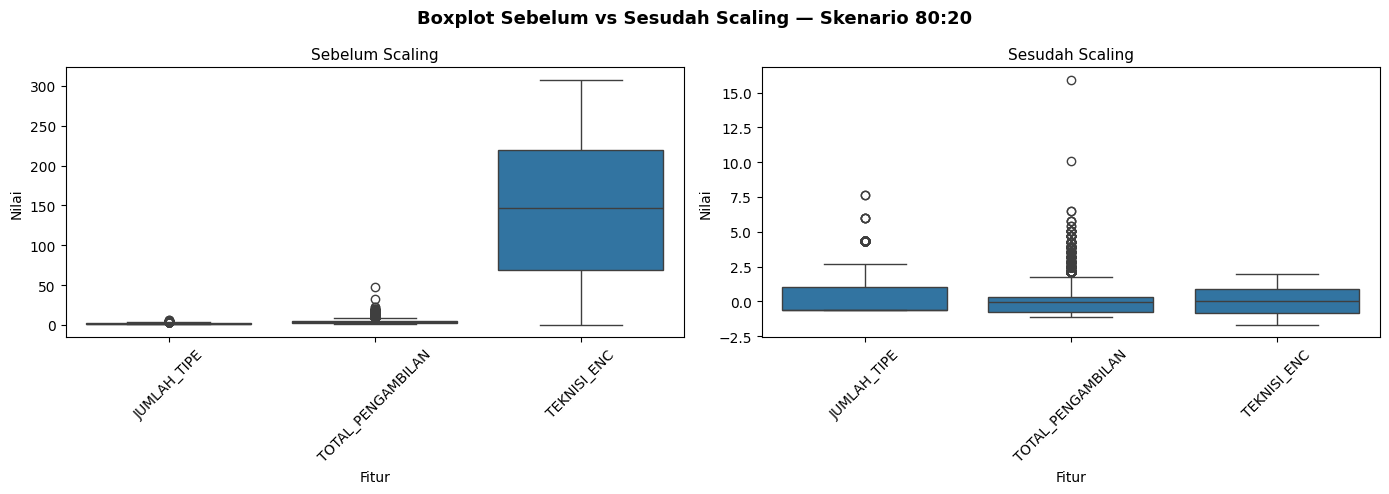


Skenario 70:30 — data setelah scaling:


,JUMLAH_TIPE,TOTAL_PENGAMBILAN,TEKNISI_ENC
0,-0.636573,-1.145594,-0.768719
1,-0.636573,-1.145594,-1.382087
2,2.677396,3.894105,1.696545
3,1.020412,-0.785616,1.437044
4,-0.636573,-1.145594,1.437044


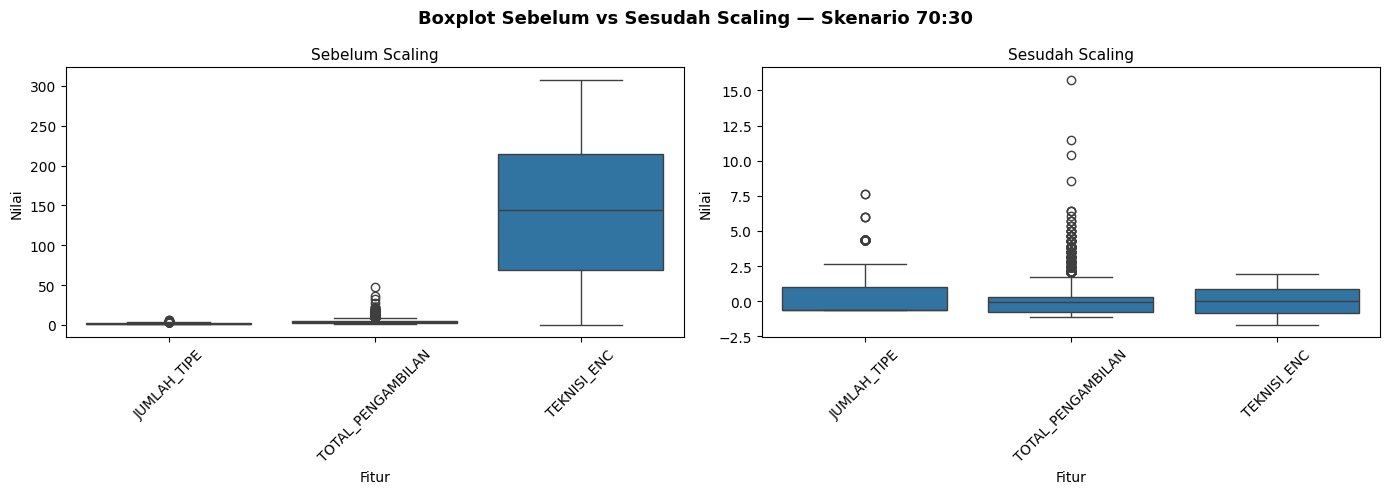

--------------------------------------------------


In [11]:
# =============================================================================
# 9. SCALING
# =============================================================================
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
 
print("=== 9. SCALING ===")
 
scaled_results = {}
 
for label, data in smote_results.items():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(data["X_train_res"])
    X_test_scaled  = scaler.transform(data["X_test"])
 
    df_before = pd.DataFrame(data["X_train_res"], columns=FEATURES)
    df_after  = pd.DataFrame(X_train_scaled,      columns=FEATURES)
 
    print(f"\nSkenario {label} — data setelah scaling:")
    display(df_after.head())
 
    # Boxplot sebelum vs sesudah scaling
    df_before_melt = df_before.melt(var_name="Fitur", value_name="Nilai")
    df_before_melt["Status"] = "Sebelum Scaling"
    df_after_melt  = df_after.melt(var_name="Fitur", value_name="Nilai")
    df_after_melt["Status"] = "Sesudah Scaling"
    df_combined = pd.concat([df_before_melt, df_after_melt], ignore_index=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Boxplot Sebelum vs Sesudah Scaling — Skenario {label}",
                 fontsize=13, fontweight="bold")
    for ax, status in zip(axes, ["Sebelum Scaling", "Sesudah Scaling"]):
        subset = df_combined[df_combined["Status"] == status]
        sns.boxplot(data=subset, x="Fitur", y="Nilai", ax=ax)
        ax.set_title(status, fontsize=11)
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
 
    scaled_results[label] = {
        "X_train_scaled": X_train_scaled,
        "X_test_scaled" : X_test_scaled,
        "y_train_res"   : data["y_train_res"],
        "y_test"        : data["y_test"],
        "scaler"        : scaler,
    }
 
print("-" * 50)

=== 10. PERBANDINGAN KERNEL SVM (TANPA SMOTE) ===

Skenario 90:10 — Hasil 4 Kernel (Tanpa SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9753,0.9755,0.9753,0.9750
1,rbf,0.9759,0.9759,0.9759,0.9759
2,poly,0.9714,0.9712,0.9714,0.9712
3,sigmoid,0.9068,0.9057,0.9068,0.9062



Skenario 80:20 — Hasil 4 Kernel (Tanpa SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9756,0.9757,0.9756,0.9753
1,rbf,0.9781,0.9780,0.9781,0.9781
2,poly,0.9705,0.9704,0.9705,0.9703
3,sigmoid,0.9054,0.9044,0.9054,0.9048



Skenario 70:30 — Hasil 4 Kernel (Tanpa SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9762,0.9764,0.9762,0.9760
1,rbf,0.9783,0.9782,0.9783,0.9783
2,poly,0.9712,0.9710,0.9712,0.9710
3,sigmoid,0.9038,0.9030,0.9038,0.9034



--- Tabel Rekapitulasi (Tanpa SMOTE) ---


Accuracy  F1 Score  Precision  Recall
Rasio Kernel                                        
70:30 linear     0.9762    0.9760     0.9764  0.9762
      poly       0.9712    0.9710     0.9710  0.9712
      rbf        0.9783    0.9783     0.9782  0.9783
      sigmoid    0.9038    0.9034     0.9030  0.9038
80:20 linear     0.9756    0.9753     0.9757  0.9756
      poly       0.9705    0.9703     0.9704  0.9705
      rbf        0.9781    0.9781     0.9780  0.9781
      sigmoid    0.9054    0.9048     0.9044  0.9054
90:10 linear     0.9753    0.9750     0.9755  0.9753
      poly       0.9714    0.9712     0.9712  0.9714
      rbf        0.9759    0.9759     0.9759  0.9759
      sigmoid    0.9068    0.9062     0.9057  0.9068

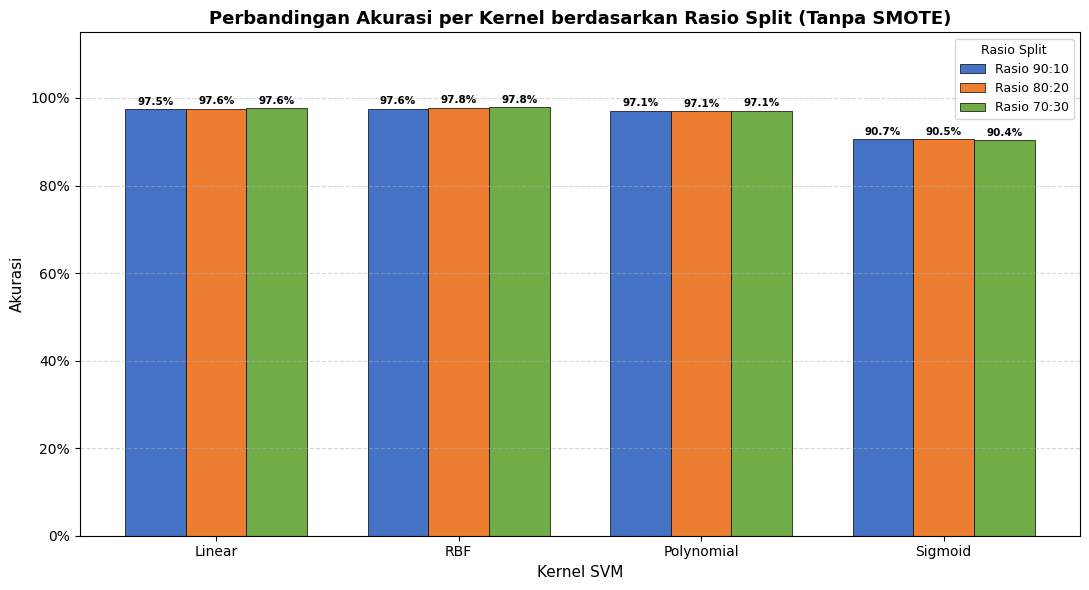

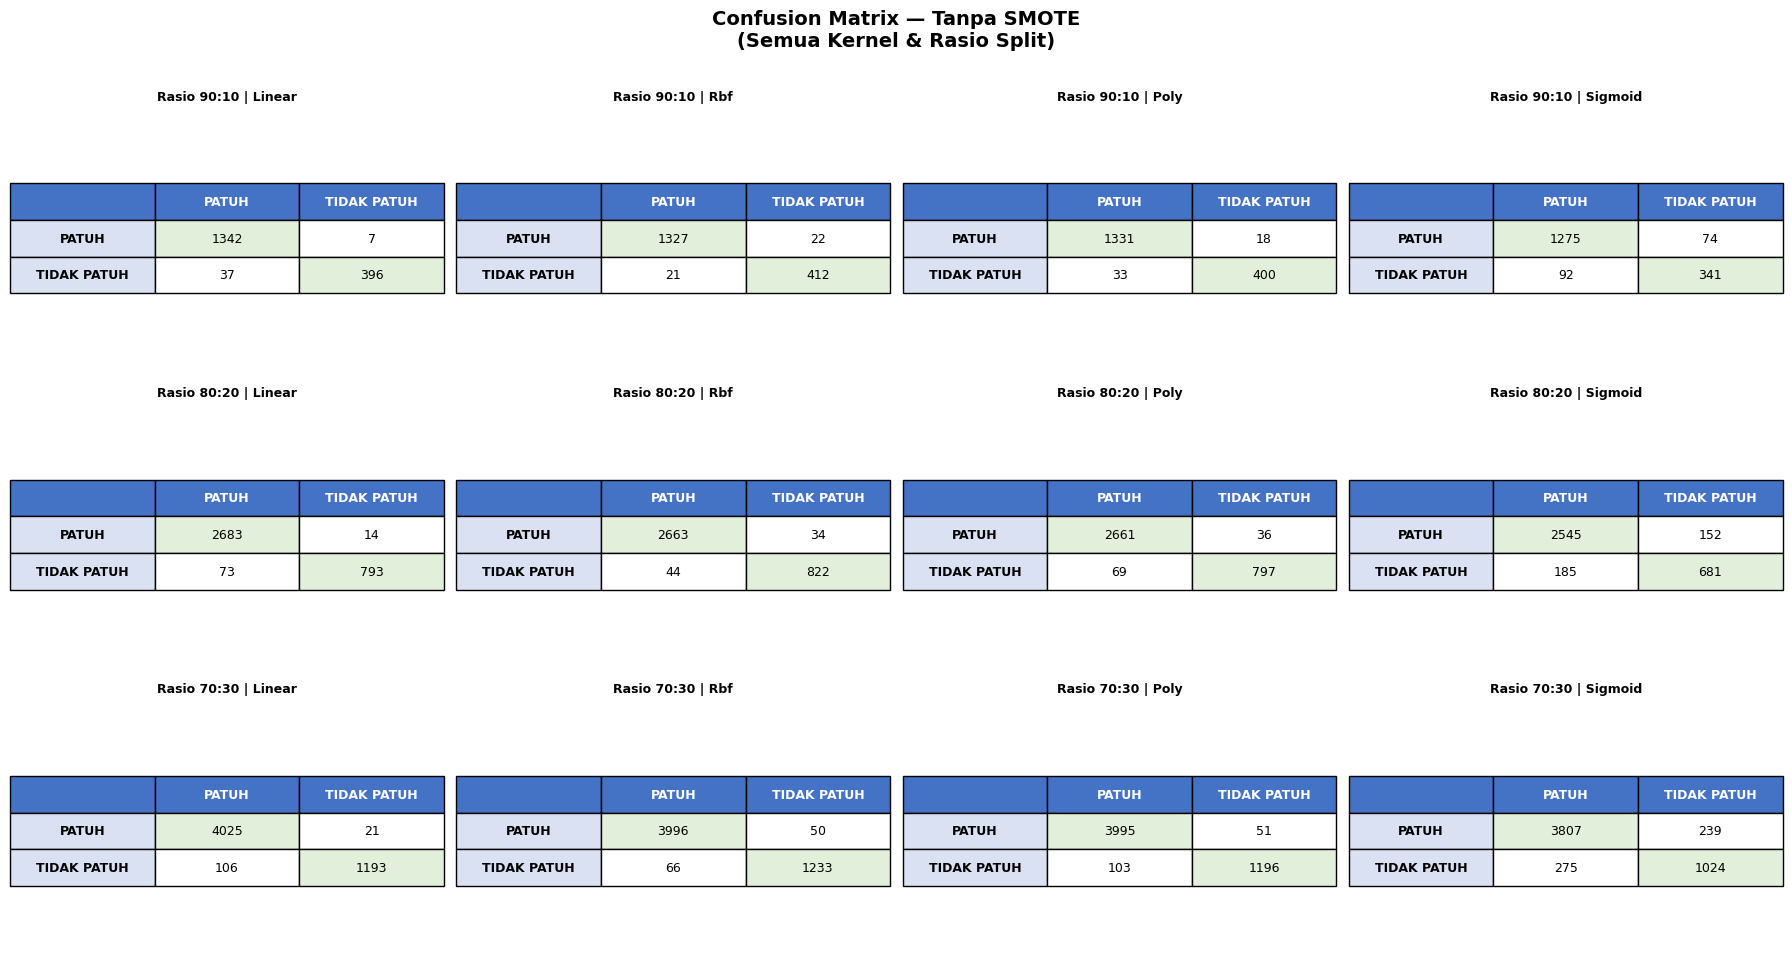

--------------------------------------------------


In [12]:
# =============================================================================
# 10. PERBANDINGAN KERNEL SVM — TANPA SMOTE
# =============================================================================
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== 10. PERBANDINGAN KERNEL SVM (TANPA SMOTE) ===")

KERNELS      = ['linear', 'rbf', 'poly', 'sigmoid']
KERNEL_NAMES = ['Linear', 'RBF', 'Polynomial', 'Sigmoid']
KELAS        = list(le_status.classes_)   # ['PATUH', 'TIDAK PATUH']

# ── Fungsi bantu evaluasi ──────────────────────────────────────────────────────
def evaluasi_kernel(X_tr, X_te, y_tr, y_te):
    rows    = []
    y_preds = {}
    for k in KERNELS:
        m  = SVC(kernel=k, random_state=42)
        m.fit(X_tr, y_tr)
        yp = m.predict(X_te)
        y_preds[k] = yp
        rows.append({
            'Kernel'   : k,
            'Accuracy' : accuracy_score(y_te, yp),
            'Precision': precision_score(y_te, yp, average='weighted', zero_division=0),
            'Recall'   : recall_score(y_te, yp, average='weighted', zero_division=0),
            'F1 Score' : f1_score(y_te, yp, average='weighted', zero_division=0),
        })
    return pd.DataFrame(rows), y_preds

# ── Fungsi visualisasi ─────────────────────────────────────────────────────────
def grouped_bar_akurasi(hasil_dict, judul):
    labels_skenario = list(hasil_dict.keys())
    x      = np.arange(len(KERNELS))
    n      = len(labels_skenario)
    width  = 0.25
    colors = ['#4472C4', '#ED7D31', '#70AD47']

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, label in enumerate(labels_skenario):
        df_m   = hasil_dict[label]["df_metrik"].set_index('Kernel')
        accs   = [df_m.loc[k, 'Accuracy'] for k in KERNELS]
        offset = (i - n / 2 + 0.5) * width
        bars   = ax.bar(x + offset, accs, width,
                        label=f"Rasio {label}",
                        color=colors[i % len(colors)],
                        edgecolor='black', linewidth=0.5)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{acc*100:.1f}%",
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_title(judul, fontsize=13, fontweight='bold')
    ax.set_xlabel("Kernel SVM", fontsize=11)
    ax.set_ylabel("Akurasi", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(KERNEL_NAMES, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
    ax.legend(title="Rasio Split", fontsize=9, title_fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def tabel_cm_skripsi(y_test, y_pred, judul):
    cm         = confusion_matrix(y_test, y_pred, labels=list(range(len(KELAS))))
    col_labels = [''] + KELAS
    row_data   = [[KELAS[i]] + list(cm[i]) for i in range(len(KELAS))]

    fig, ax = plt.subplots(figsize=(5.5, 2.2))
    ax.axis('off')
    fig.suptitle(judul, fontsize=9.5, fontweight='bold', y=1.04)

    tabel = ax.table(cellText=row_data, colLabels=col_labels,
                     cellLoc='center', loc='center')
    tabel.auto_set_font_size(False)
    tabel.set_fontsize(10)
    tabel.scale(1.6, 2.0)

    for col in range(len(col_labels)):
        cell = tabel[0, col]
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')
    for row in range(1, len(KELAS) + 1):
        cell = tabel[row, 0]
        cell.set_facecolor('#D9E1F2')
        cell.set_text_props(fontweight='bold')
    for i in range(1, len(KELAS) + 1):
        tabel[i, i].set_facecolor('#E2EFDA')

    plt.tight_layout()
    plt.show()

def ringkasan_cm_grid(hasil_dict, kondisi_label):
    rasios  = list(hasil_dict.keys())
    n_rasio = len(rasios)
    n_kern  = len(KERNELS)

    fig, axes = plt.subplots(
        n_rasio, n_kern,
        figsize=(4.5 * n_kern, 3.2 * n_rasio)
    )
    fig.suptitle(
        f"Confusion Matrix — {kondisi_label}\n(Semua Kernel & Rasio Split)",
        fontsize=14, fontweight='bold', y=1.01
    )

    for r, rasio in enumerate(rasios):
        y_t     = hasil_dict[rasio]["y_test"]
        y_preds = hasil_dict[rasio]["y_preds"]
        for c, kernel in enumerate(KERNELS):
            ax = axes[r][c] if n_rasio > 1 else axes[c]
            yp = y_preds[kernel]
            cm = confusion_matrix(y_t, yp, labels=list(range(len(KELAS))))

            col_labels = [''] + KELAS
            row_data   = [[KELAS[i]] + list(cm[i]) for i in range(len(KELAS))]

            ax.axis('off')
            ax.set_title(f"Rasio {rasio} | {kernel.capitalize()}",
                         fontsize=9, fontweight='bold', pad=4)

            tabel = ax.table(cellText=row_data, colLabels=col_labels,
                             cellLoc='center', loc='center')
            tabel.auto_set_font_size(False)
            tabel.set_fontsize(9)
            tabel.scale(1.4, 1.8)

            for col in range(len(col_labels)):
                cell = tabel[0, col]
                cell.set_facecolor('#4472C4')
                cell.set_text_props(color='white', fontweight='bold')
            for row in range(1, len(KELAS) + 1):
                cell = tabel[row, 0]
                cell.set_facecolor('#D9E1F2')
                cell.set_text_props(fontweight='bold')
            for i in range(1, len(KELAS) + 1):
                tabel[i, i].set_facecolor('#E2EFDA')

    plt.tight_layout()
    plt.show()

def buat_rekap(hasil_dict, label_kondisi):
    rows = []
    for rasio, v in hasil_dict.items():
        for _, row in v["df_metrik"].iterrows():
            rows.append({
                'Kondisi'  : label_kondisi,
                'Rasio'    : rasio,
                'Kernel'   : row['Kernel'],
                'Accuracy' : row['Accuracy'],
                'Precision': row['Precision'],
                'Recall'   : row['Recall'],
                'F1 Score' : row['F1 Score'],
            })
    return pd.DataFrame(rows)

# =============================================================================
# TRAINING & EVALUASI — TANPA SMOTE
# =============================================================================
hasil_tanpa_smote = {}

for label, (X_train, X_test, y_train, y_test) in splits.items():
    scaler_tmp    = StandardScaler()
    X_tr_sc       = scaler_tmp.fit_transform(X_train)
    X_te_sc       = scaler_tmp.transform(X_test)
    df_m, y_preds = evaluasi_kernel(X_tr_sc, X_te_sc, y_train, y_test)

    print(f"\nSkenario {label} — Hasil 4 Kernel (Tanpa SMOTE):")
    pd.set_option('display.float_format', '{:.4f}'.format)
    display(df_m)
    pd.reset_option('display.float_format')

    hasil_tanpa_smote[label] = {
        "df_metrik": df_m,
        "y_preds"  : y_preds,
        "y_test"   : y_test,
    }

# ── Tabel Rekapitulasi ────────────────────────────────────────────────────────
print("\n--- Tabel Rekapitulasi (Tanpa SMOTE) ---")

df_rekap_tanpa = buat_rekap(hasil_tanpa_smote, "Tanpa SMOTE")
pd.set_option('display.float_format', '{:.4f}'.format)
display(df_rekap_tanpa.pivot_table(
    index=['Rasio', 'Kernel'],
    values=['Accuracy', 'Precision', 'Recall', 'F1 Score']
))
pd.reset_option('display.float_format')

# ── Diagram Akurasi Gabungan ───────────────────────────────────────────────────
grouped_bar_akurasi(
    hasil_tanpa_smote,
    "Perbandingan Akurasi per Kernel berdasarkan Rasio Split (Tanpa SMOTE)"
)

# ── Confusion Matrix Grid ─────────────────────────────────────────────────────
ringkasan_cm_grid(hasil_tanpa_smote, "Tanpa SMOTE")

print("-" * 50)

=== 11. PERBANDINGAN KERNEL SVM (DENGAN SMOTE) ===

Skenario 90:10 — Hasil 4 Kernel (Dengan SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9675,0.9713,0.9675,0.9681
1,rbf,0.9703,0.9731,0.9703,0.9708
2,poly,0.9383,0.9491,0.9383,0.9403
3,sigmoid,0.9141,0.9238,0.9141,0.9166



Skenario 80:20 — Hasil 4 Kernel (Dengan SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9722,0.9751,0.9722,0.9727
1,rbf,0.9739,0.9760,0.9739,0.9743
2,poly,0.9377,0.9489,0.9377,0.9398
3,sigmoid,0.9192,0.9271,0.9192,0.9212



Skenario 70:30 — Hasil 4 Kernel (Dengan SMOTE):


,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9717,0.9747,0.9717,0.9723
1,rbf,0.9749,0.9768,0.9749,0.9753
2,poly,0.9392,0.9501,0.9392,0.9412
3,sigmoid,0.9186,0.9267,0.9186,0.9207



--- Tabel Rekapitulasi (Dengan SMOTE) ---


Accuracy  F1 Score  Precision  Recall
Rasio Kernel                                        
70:30 linear     0.9717    0.9723     0.9747  0.9717
      poly       0.9392    0.9412     0.9501  0.9392
      rbf        0.9749    0.9753     0.9768  0.9749
      sigmoid    0.9186    0.9207     0.9267  0.9186
80:20 linear     0.9722    0.9727     0.9751  0.9722
      poly       0.9377    0.9398     0.9489  0.9377
      rbf        0.9739    0.9743     0.9760  0.9739
      sigmoid    0.9192    0.9212     0.9271  0.9192
90:10 linear     0.9675    0.9681     0.9713  0.9675
      poly       0.9383    0.9403     0.9491  0.9383
      rbf        0.9703    0.9708     0.9731  0.9703
      sigmoid    0.9141    0.9166     0.9238  0.9141

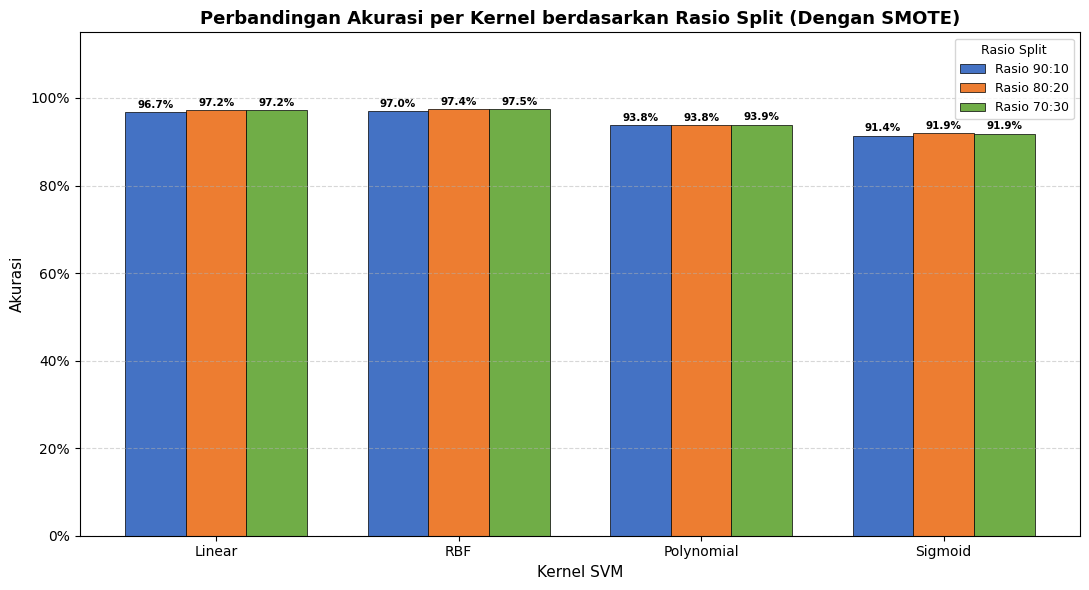

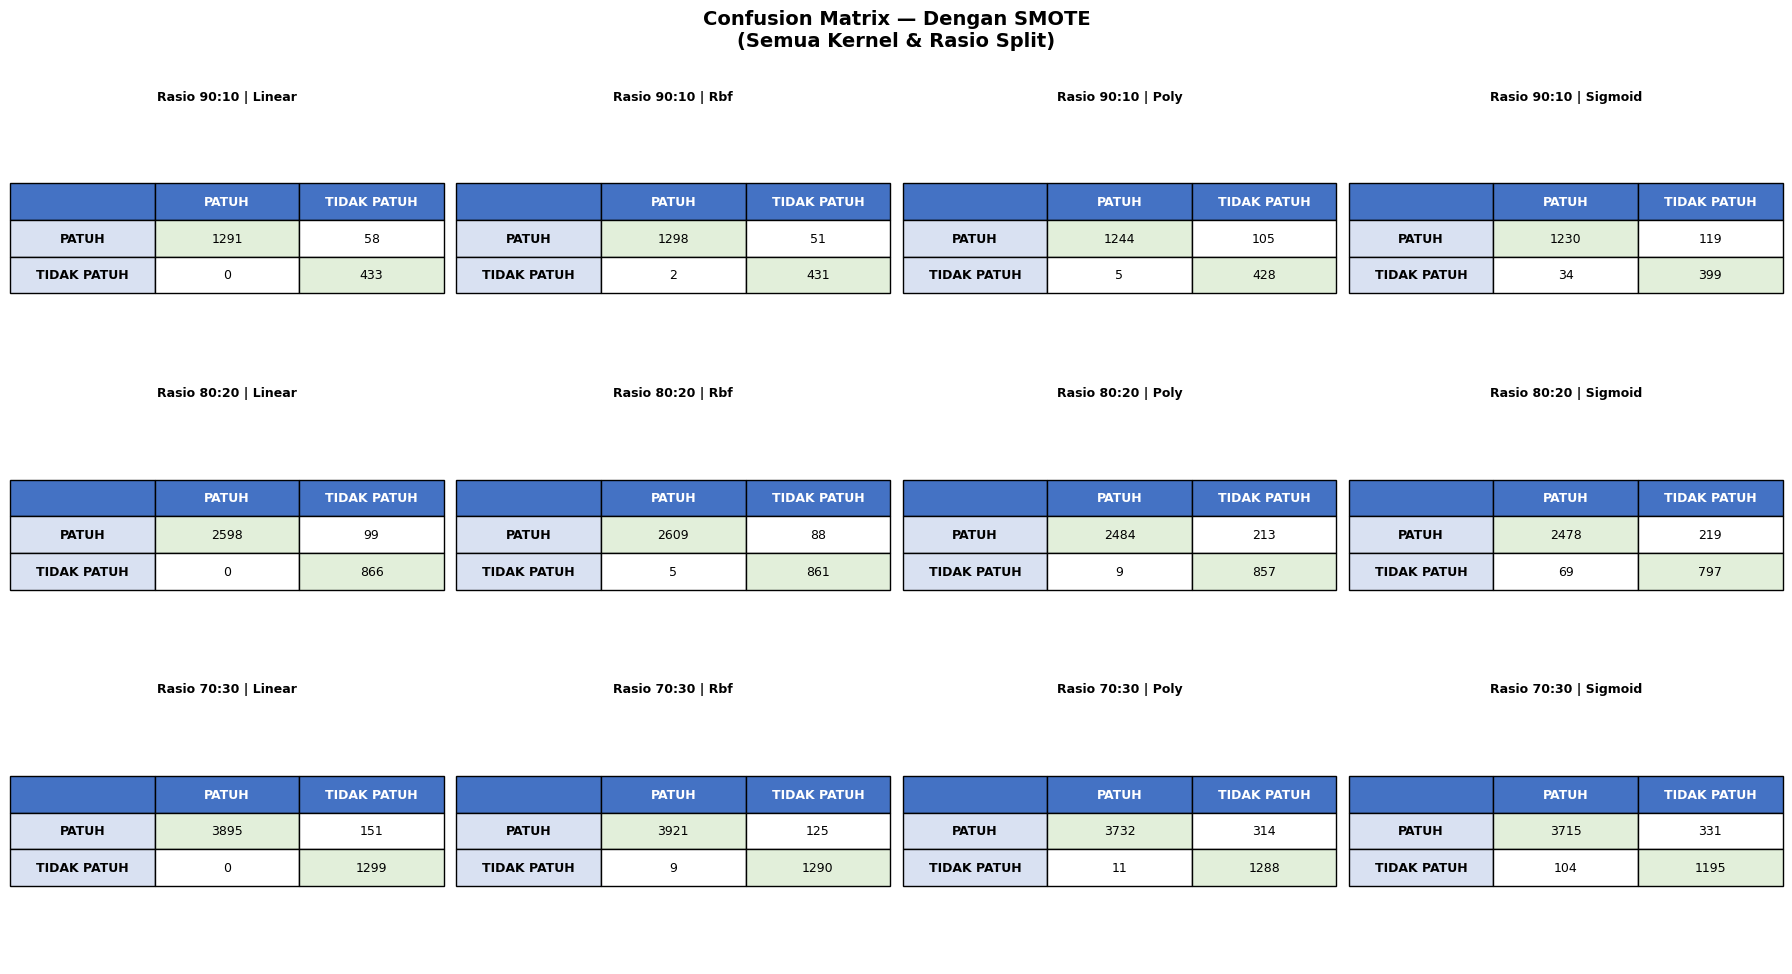

--------------------------------------------------


In [13]:
# =============================================================================
# 11. PERBANDINGAN KERNEL SVM — DENGAN SMOTE
# =============================================================================
print("=== 11. PERBANDINGAN KERNEL SVM (DENGAN SMOTE) ===")

hasil_dengan_smote = {}

for label, data in scaled_results.items():
    df_m, y_preds = evaluasi_kernel(
        data["X_train_scaled"], data["X_test_scaled"],
        data["y_train_res"],    data["y_test"]
    )

    print(f"\nSkenario {label} — Hasil 4 Kernel (Dengan SMOTE):")
    pd.set_option('display.float_format', '{:.4f}'.format)
    display(df_m)
    pd.reset_option('display.float_format')

    hasil_dengan_smote[label] = {
        "df_metrik": df_m,
        "y_preds"  : y_preds,
        "y_test"   : data["y_test"],
    }

# ── Tabel Rekapitulasi ────────────────────────────────────────────────────────
print("\n--- Tabel Rekapitulasi (Dengan SMOTE) ---")

df_rekap_smote = buat_rekap(hasil_dengan_smote, "Dengan SMOTE")
pd.set_option('display.float_format', '{:.4f}'.format)
display(df_rekap_smote.pivot_table(
    index=['Rasio', 'Kernel'],
    values=['Accuracy', 'Precision', 'Recall', 'F1 Score']
))
pd.reset_option('display.float_format')

# ── Diagram Akurasi Gabungan ───────────────────────────────────────────────────
grouped_bar_akurasi(
    hasil_dengan_smote,
    "Perbandingan Akurasi per Kernel berdasarkan Rasio Split (Dengan SMOTE)"
)

# ── Confusion Matrix Grid (semua kernel & rasio) ──────────────────────────────
ringkasan_cm_grid(hasil_dengan_smote, "Dengan SMOTE")

print("-" * 50)

=== 12. PENENTUAN HYPERPARAMETER (GridSearchCV) ===
Skenario terbaik : 70:30
Kernel terbaik   : rbf
F1 Score ref     : 0.9753

Menjalankan GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best Parameters : {'C': 10, 'gamma': 'scale'}
Best CV F1 Score: 0.9817

=== HASIL MODEL TERBAIK (Test Set) ===


,Kernel,Best Params,Accuracy,Precision,Recall,F1 Score
0,rbf,"kernel=rbf, C=10, gamma='scale'(0.3333)",0.9749,0.9768,0.9749,0.9753


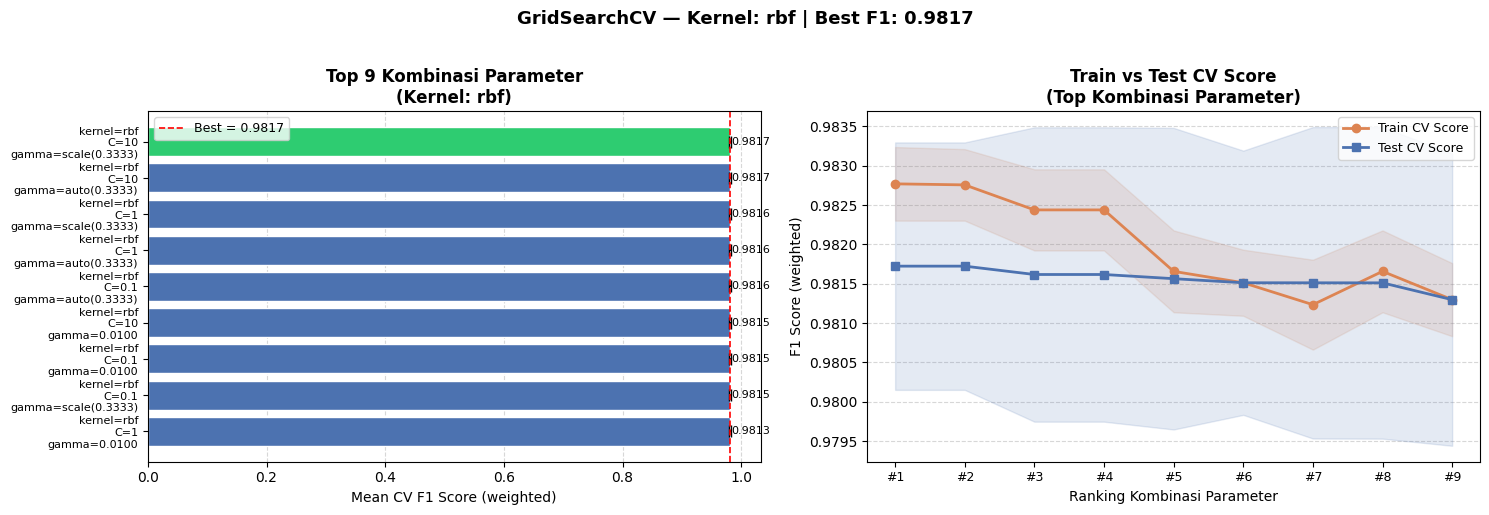

✅ grid_results berhasil disimpan.
--------------------------------------------------


In [19]:
# =============================================================================
# 12. PENENTUAN HYPERPARAMETER (GridSearchCV) — pada skenario & kondisi terbaik
# =============================================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
 
print("=== 12. PENENTUAN HYPERPARAMETER (GridSearchCV) ===")
 
# ── Tentukan kernel & skenario terbaik dari hasil Dengan SMOTE ────────────────
best_rasio  = None
best_kernel = None
best_f1_ref = -1
 
for rasio, v in hasil_dengan_smote.items():
    row = v["df_metrik"].loc[v["df_metrik"]["F1 Score"].idxmax()]
    if row["F1 Score"] > best_f1_ref:
        best_f1_ref = row["F1 Score"]
        best_kernel = row["Kernel"]
        best_rasio  = rasio
 
print(f"Skenario terbaik : {best_rasio}")
print(f"Kernel terbaik   : {best_kernel}")
print(f"F1 Score ref     : {best_f1_ref:.4f}\n")
 
# ── Ambil data scaled dari skenario terbaik ───────────────────────────────────
X_train_scaled = scaled_results[best_rasio]["X_train_scaled"]
X_test_scaled  = scaled_results[best_rasio]["X_test_scaled"]
y_train_res    = scaled_results[best_rasio]["y_train_res"]
y_test         = scaled_results[best_rasio]["y_test"]
 
# ── Parameter grid ────────────────────────────────────────────────────────────
param_grids = {
    'linear' : {'C': [0.1, 1, 10]},
    'rbf'    : {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01]},
    'poly'   : {'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale']},
    'sigmoid': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
}
 
param_grid  = param_grids[best_kernel]
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
grid_search = GridSearchCV(
    SVC(kernel=best_kernel, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1,
    return_train_score=True
)
 
print("Menjalankan GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_res)
 
# ── Helper ────────────────────────────────────────────────────────────────────
def resolve_gamma(params, X):
    gamma_val = params.get('gamma', None)
    if gamma_val is None:
        return None
    n_features = X.shape[1]
    if gamma_val == 'scale':
        return 1 / (n_features * X.var())
    elif gamma_val == 'auto':
        return 1 / n_features
    return gamma_val
 
def format_params_display(params, X):
    parts = [f"kernel={best_kernel}", f"C={params['C']}"]
    g = params.get('gamma', None)
    if g is not None:
        g_actual = resolve_gamma(params, X)
        parts.append(f"gamma={g!r}({g_actual:.4f})" if isinstance(g, str)
                     else f"gamma={g_actual:.4f}")
    if 'degree' in params:
        parts.append(f"degree={params['degree']}")
    return ', '.join(parts)
 
def make_param_label(params, X):
    lines = [f"kernel={best_kernel}", f"C={params['C']}"]
    g = params.get('gamma', None)
    if g is not None:
        g_actual = resolve_gamma(params, X)
        lines.append(f"gamma={g}({g_actual:.4f})" if isinstance(g, str)
                     else f"gamma={g:.4f}")
    if 'degree' in params:
        lines.append(f"degree={params['degree']}")
    return '\n'.join(lines)
 
# ── Hasil best params ─────────────────────────────────────────────────────────
best_params    = grid_search.best_params_
best_cv_score  = grid_search.best_score_
gamma_actual   = resolve_gamma(best_params, X_train_scaled)
params_display = format_params_display(best_params, X_train_scaled)
 
print(f"\nBest Parameters : {best_params}")
print(f"Best CV F1 Score: {best_cv_score:.4f}")
 
# ── Evaluasi pada test set ────────────────────────────────────────────────────
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
 
acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
rec_best  = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1_best   = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)
 
df_best = pd.DataFrame(
    [[best_kernel, params_display, acc_best, prec_best, rec_best, f1_best]],
    columns=['Kernel', 'Best Params', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)
print("\n=== HASIL MODEL TERBAIK (Test Set) ===")
pd.set_option('display.float_format', '{:.4f}'.format)
display(df_best)
pd.reset_option('display.float_format')
 
# ── Visualisasi CV results ────────────────────────────────────────────────────
cv_results  = pd.DataFrame(grid_search.cv_results_)
cv_results  = cv_results.sort_values('mean_test_score', ascending=False).reset_index(drop=True)
top_n       = min(10, len(cv_results))
top_results = cv_results.head(top_n).copy()
top_results['param_label'] = top_results['params'].apply(
    lambda p: make_param_label(p, X_train_scaled)
)
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
colors_bar = ['#2ecc71' if i == 0 else '#4C72B0' for i in range(top_n)]
bars = axes[0].barh(range(top_n), top_results['mean_test_score'],
                    xerr=top_results['std_test_score'],
                    color=colors_bar, edgecolor='white', align='center', capsize=4)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_results['param_label'], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean CV F1 Score (weighted)', fontsize=10)
axes[0].set_title(f'Top {top_n} Kombinasi Parameter\n(Kernel: {best_kernel})',
                  fontsize=12, fontweight='bold')
axes[0].axvline(best_cv_score, color='red', linestyle='--', linewidth=1.2,
                label=f'Best = {best_cv_score:.4f}')
axes[0].legend(fontsize=9)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)
for bar, val in zip(bars, top_results['mean_test_score']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8)
 
x_idx = range(top_n)
axes[1].plot(x_idx, top_results['mean_train_score'], 'o-',
             color='#DD8452', label='Train CV Score', linewidth=2)
axes[1].plot(x_idx, top_results['mean_test_score'], 's-',
             color='#4C72B0', label='Test CV Score', linewidth=2)
axes[1].fill_between(x_idx,
    top_results['mean_train_score'] - top_results['std_train_score'],
    top_results['mean_train_score'] + top_results['std_train_score'],
    alpha=0.15, color='#DD8452')
axes[1].fill_between(x_idx,
    top_results['mean_test_score'] - top_results['std_test_score'],
    top_results['mean_test_score'] + top_results['std_test_score'],
    alpha=0.15, color='#4C72B0')
axes[1].set_xticks(list(x_idx))
axes[1].set_xticklabels([f'#{i+1}' for i in x_idx], fontsize=9)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=10)
axes[1].set_xlabel('Ranking Kombinasi Parameter', fontsize=10)
axes[1].set_title('Train vs Test CV Score\n(Top Kombinasi Parameter)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)
 
fig.suptitle(f'GridSearchCV — Kernel: {best_kernel} | Best F1: {best_cv_score:.4f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
# ── Simpan grid_results ───────────────────────────────────────────────────────
grid_results = {
    best_kernel: {
        'best_params'    : best_params,
        'best_cv_score'  : best_cv_score,
        'best_estimator' : best_model,
        'y_pred'         : y_pred_best,
        'accuracy'       : acc_best,
        'precision'      : prec_best,
        'recall'         : rec_best,
        'f1'             : f1_best,
        'params_display' : params_display,
    }
}
print("✅ grid_results berhasil disimpan.")
print("-" * 50)

=== 13. MODEL FINAL & EVALUASI ===

Kernel      : rbf
Best Params : kernel=rbf, C=10, gamma='scale'(0.3333)
Best CV F1  : 0.9820

--- 13a. Classification Report ---
              precision    recall  f1-score   support

       PATUH       1.00      0.97      0.98      4046
 TIDAK PATUH       0.91      0.99      0.95      1299

    accuracy                           0.97      5345
   macro avg       0.95      0.98      0.97      5345
weighted avg       0.98      0.97      0.98      5345

--- 13b. Confusion Matrix (Heatmap) ---


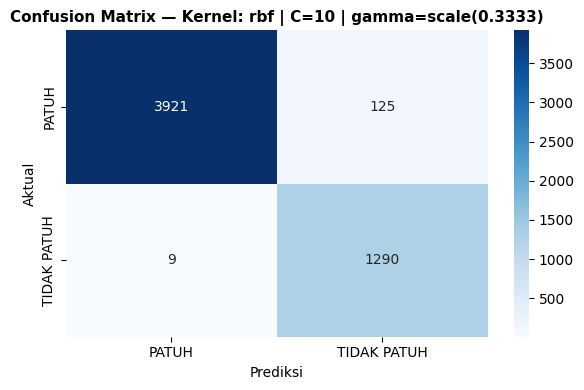

--- 13c. Confusion Matrix ---


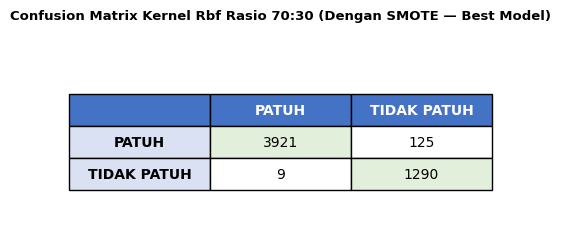

--- 13d. Hasil Prediksi Per Data (10 Baris Pertama) ---


,Aktual,Prediksi,Benar
0,PATUH,PATUH,True
1,TIDAK PATUH,TIDAK PATUH,True
2,PATUH,PATUH,True
3,PATUH,PATUH,True
4,PATUH,PATUH,True
5,PATUH,PATUH,True
6,PATUH,PATUH,True
7,PATUH,PATUH,True
8,PATUH,PATUH,True
9,PATUH,PATUH,True


,Keterangan,Nilai
0,Total Data,5345
1,Prediksi Benar,5211
2,Prediksi Salah,134
3,Akurasi (%),97.49%


--------------------------------------------------


In [15]:
# =============================================================================
# 13. MODEL FINAL & EVALUASI
# =============================================================================
from sklearn.metrics import classification_report
 
print("=== 13. MODEL FINAL & EVALUASI ===")
 
res          = grid_results[best_kernel]
y_pred_final = res['y_pred']
 
print(f"\nKernel      : {best_kernel}")
print(f"Best Params : {res['params_display']}")
print(f"Best CV F1  : {res['best_cv_score']:.4f}")
 
# ── 13a. Classification Report ───────────────────────────────────────────────
print("\n--- 13a. Classification Report ---")
print(classification_report(y_test, y_pred_final,
                             target_names=le_status.classes_, zero_division=0))
 
# ── 13b. Confusion Matrix (heatmap) ─────────────────────────────────────────
print("--- 13b. Confusion Matrix (Heatmap) ---")
cm = confusion_matrix(y_test, y_pred_final)
 
gamma_actual = resolve_gamma(res['best_params'], X_train_scaled)
gamma_info   = (f" | gamma={res['best_params'].get('gamma','')}({gamma_actual:.4f})"
                if gamma_actual is not None else "")
cm_title = (f"Confusion Matrix — Kernel: {best_kernel} | "
            f"C={res['best_params']['C']}{gamma_info}")
 
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_,
            yticklabels=le_status.classes_, ax=ax)
ax.set_title(cm_title, fontsize=11, fontweight='bold')
ax.set_xlabel('Prediksi', fontsize=10)
ax.set_ylabel('Aktual', fontsize=10)
plt.tight_layout()
plt.show()
 
# ── 13c. Confusion Matrix (format tabel skripsi) ─────────────────────────────
print("--- 13c. Confusion Matrix ---")
tabel_cm_skripsi(
    y_test, y_pred_final,
    f"Confusion Matrix Kernel {best_kernel.capitalize()} "
    f"Rasio {best_rasio} (Dengan SMOTE — Best Model)"
)
 
# ── 13d. Hasil prediksi 10 baris pertama ─────────────────────────────────────
print("--- 13d. Hasil Prediksi Per Data (10 Baris Pertama) ---")
df_prediksi = pd.DataFrame({
    'Aktual'  : le_status.inverse_transform(y_test),
    'Prediksi': le_status.inverse_transform(y_pred_final)
})
df_prediksi['Benar'] = df_prediksi['Aktual'] == df_prediksi['Prediksi']
display(df_prediksi.head(10))
 
# ── 13e. Ringkasan akurasi ───────────────────────────────────────────────────
total   = len(df_prediksi)
correct = df_prediksi['Benar'].sum()
wrong   = total - correct
 
df_ringkasan = pd.DataFrame({
    'Keterangan': ['Total Data', 'Prediksi Benar', 'Prediksi Salah', 'Akurasi (%)'],
    'Nilai'     : [total, correct, wrong, f"{correct/total*100:.2f}%"]
})
display(df_ringkasan)
print("-" * 50)

In [16]:
# =============================================================================
# 14. SIMPAN MODEL & ARTEFAK
# =============================================================================
import pickle
 
print("=== 14. SIMPAN MODEL & ARTEFAK ===")
 
scaler = scaled_results[best_rasio]["scaler"]
 
artefak = {
    "model_svm.pkl" : best_model,
    "scaler.pkl"    : scaler,
    "le_teknisi.pkl": le_teknisi,
}
 
semua_berhasil = True
for nama_file, objek in artefak.items():
    try:
        pickle.dump(objek, open(nama_file, "wb"))
        print(f"  ✅ {nama_file:<20} → tersimpan")
    except Exception as e:
        print(f"  ❌ {nama_file:<20} → GAGAL: {e}")
        semua_berhasil = False
 
if semua_berhasil:
    print("\nSemua artefak berhasil disimpan.")
else:
    print("\n⚠️  Ada artefak yang gagal disimpan.")
 
print("-" * 50)

=== 14. SIMPAN MODEL & ARTEFAK ===
  ✅ model_svm.pkl        → tersimpan
  ✅ scaler.pkl           → tersimpan
  ✅ le_teknisi.pkl       → tersimpan

Semua artefak berhasil disimpan.
--------------------------------------------------


In [17]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install plotly